In [1]:
import pandas as pd
import numpy as np
from statsmodels.tsa.stattools import adfuller
import mplfinance as mp
import matplotlib.pyplot as plt
import seaborn as sns

C:\Users\Harsh\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
up_trend =pd.read_csv("NIFTY 50-12-03-2025-to-27-06-2025.csv")
down_trend = pd.read_csv("NIFTY 50-13-12-2024-to-04-03-2025.csv")
side_trend = pd.read_csv("NIFTY 50-01-07-2025-to-10-10-2025.csv")

In [3]:
up_trend

,Date,Open,High,Low,Close,Shares Traded,Turnover (₹ Cr)
0,27-JUN-2025,25576.65,25654.20,25523.55,25637.80,563957748,47108.60
1,26-JUN-2025,25268.95,25565.30,25259.90,25549.00,428891818,38689.39
2,25-JUN-2025,25150.35,25266.80,25125.05,25244.75,260582584,22985.17
3,24-JUN-2025,25179.90,25317.70,24999.70,25044.35,450185468,35508.90
4,23-JUN-2025,24939.75,25057.00,24824.85,24971.90,248534153,20797.88
...,...,...,...,...,...,...,...
67,19-MAR-2025,22874.95,22940.70,22807.95,22907.60,323992121,26994.95
68,18-MAR-2025,22662.25,22857.80,22599.20,22834.30,272578844,26387.47
69,17-MAR-2025,22353.15,22577.00,22353.15,22508.75,251102239,24122.27
70,13-MAR-2025,22541.50,22558.05,22377.35,22397.20,287535243,22855.58


In [4]:
up_trend.columns

Index(['Date ', 'Open ', 'High ', 'Low ', 'Close ', 'Shares Traded ',
       'Turnover (₹ Cr)'],
      dtype='object')

# up trend dataset

In [5]:
up_trend.columns = up_trend.columns.str.strip()
print(up_trend.columns)

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Shares Traded',
       'Turnover (₹ Cr)'],
      dtype='object')


In [6]:
print(up_trend.index)

RangeIndex(start=0, stop=72, step=1)


In [7]:
from datetime import date
up_trend['Date'] = pd.to_datetime(up_trend['Date'])
up_trend = up_trend.sort_values('Date')

C:\Users\Harsh\AppData\Local\Temp\ipykernel_18044\2181276351.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  up_trend['Date'] = pd.to_datetime(up_trend['Date'])


In [8]:
up_trend = up_trend.sort_values('Date', ascending= True).reset_index(drop=True)

# for reverse the data set
up_trend

,Date,Open,High,Low,Close,Shares Traded,Turnover (₹ Cr)
0,2025-03-12,22536.35,22577.40,22329.55,22470.50,369736725,33406.41
1,2025-03-13,22541.50,22558.05,22377.35,22397.20,287535243,22855.58
2,2025-03-17,22353.15,22577.00,22353.15,22508.75,251102239,24122.27
3,2025-03-18,22662.25,22857.80,22599.20,22834.30,272578844,26387.47
4,2025-03-19,22874.95,22940.70,22807.95,22907.60,323992121,26994.95
...,...,...,...,...,...,...,...
67,2025-06-23,24939.75,25057.00,24824.85,24971.90,248534153,20797.88
68,2025-06-24,25179.90,25317.70,24999.70,25044.35,450185468,35508.90
69,2025-06-25,25150.35,25266.80,25125.05,25244.75,260582584,22985.17
70,2025-06-26,25268.95,25565.30,25259.90,25549.00,428891818,38689.39


<Axes: >

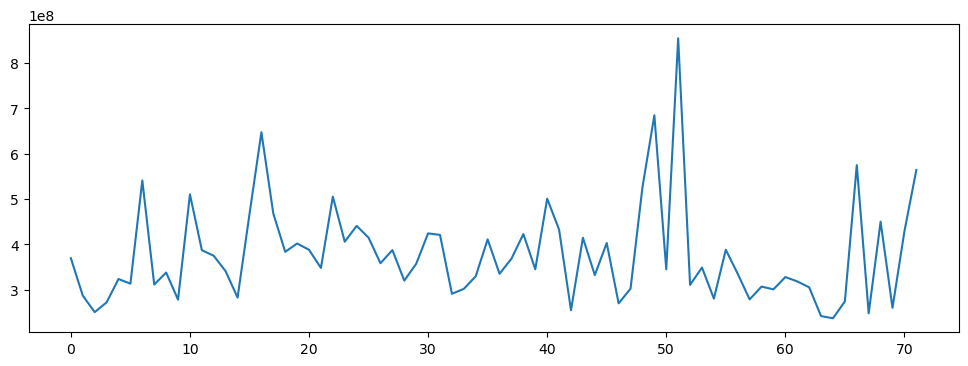

In [9]:
up_trend['Shares Traded'].plot(figsize=(12,4))

<Axes: >

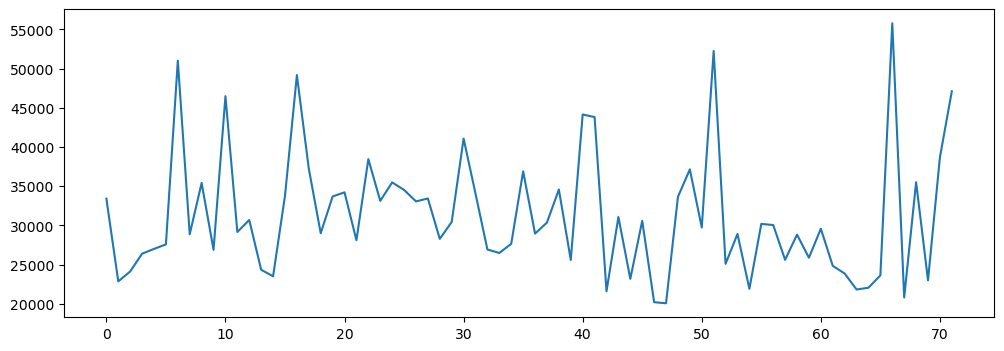

In [10]:
up_trend['Turnover (₹ Cr)'].plot(figsize =(12,4))

In [11]:
up_trend.index = pd.to_datetime(up_trend.index)

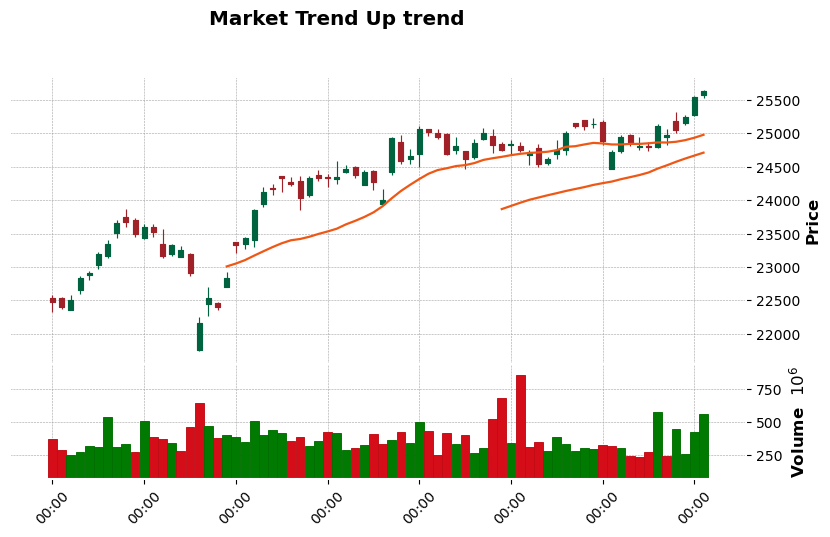

In [12]:
up_trend.rename(columns={'Shares Traded':'Volume'}, inplace=True)

mp.plot(up_trend,type='candle',volume=True,mav=(20,50,200),style='charles',figratio=(16,9),title='Market Trend Up trend')

# down Trend dataset

In [13]:
down_trend

,Date,Open,High,Low,Close,Shares Traded,Turnover (₹ Cr)
0,04-MAR-2025,21974.45,22105.05,21964.60,22082.65,253260641,22979.56
1,03-MAR-2025,22194.55,22261.55,22004.70,22119.30,282399735,25942.05
2,28-FEB-2025,22433.40,22450.35,22104.85,22124.70,551285287,52745.20
3,27-FEB-2025,22568.95,22613.30,22508.40,22545.05,289230479,29775.64
4,25-FEB-2025,22516.45,22625.30,22513.90,22547.55,250279519,24917.83
5,24-FEB-2025,22609.35,22668.05,22518.80,22553.35,214317552,20772.95
6,21-FEB-2025,22857.20,22921.00,22720.30,22795.90,242753984,21994.37
7,20-FEB-2025,22821.10,22923.85,22812.75,22913.15,240836647,21303.88
8,19-FEB-2025,22847.25,23049.95,22814.85,22932.90,206999204,19817.93
9,18-FEB-2025,22963.65,22992.50,22801.50,22945.30,210616675,19431.37


In [14]:
down_trend.columns = down_trend.columns.str.strip()

In [15]:
down_trend['Date'] = pd.to_datetime(down_trend['Date'])
down_trend = down_trend.sort_values('Date')

C:\Users\Harsh\AppData\Local\Temp\ipykernel_18044\462889963.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  down_trend['Date'] = pd.to_datetime(down_trend['Date'])


In [16]:
down_trend = down_trend.sort_values('Date',ascending=True).reset_index(drop = True)

<Axes: >

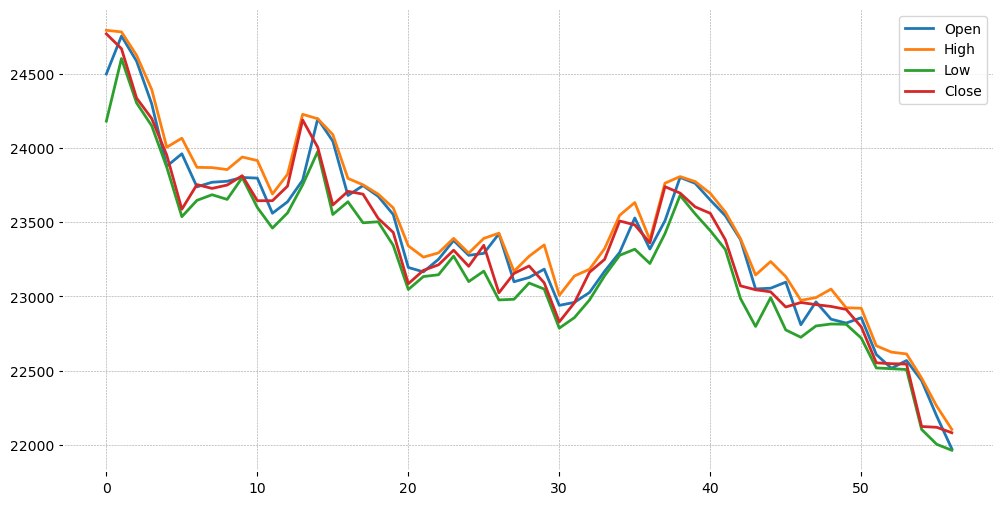

In [17]:
down_trend[['Open','High','Low','Close']].plot(figsize=(12,6))

<Axes: >

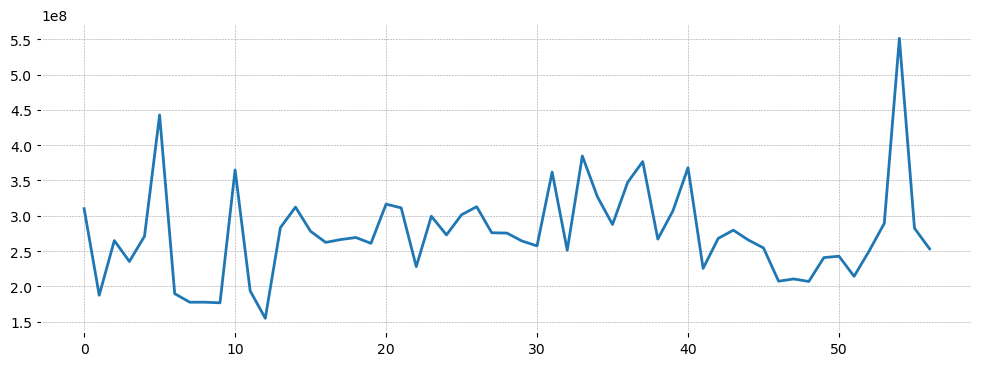

In [18]:
down_trend['Shares Traded'].plot(figsize =(12,4))

<Axes: >

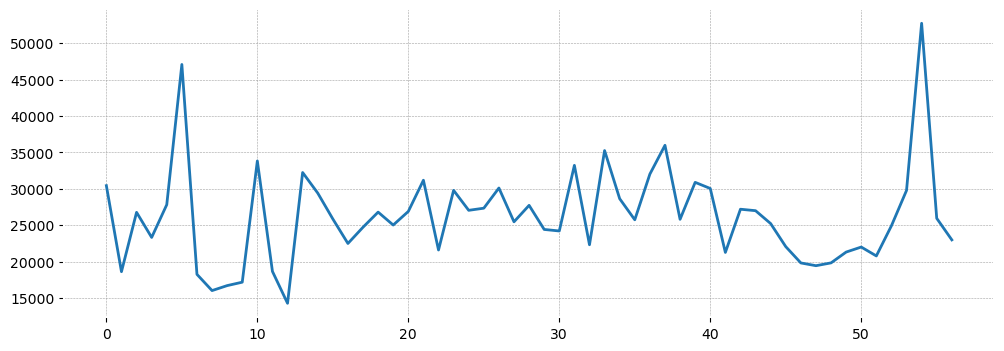

In [19]:
down_trend['Turnover (₹ Cr)'].plot(figsize=(12,4))

In [20]:
print(type(down_trend.index))

<class 'pandas.core.indexes.range.RangeIndex'>


In [21]:
down_trend.index = pd.to_datetime(down_trend.index)
#Force convert to DatetimeIndex

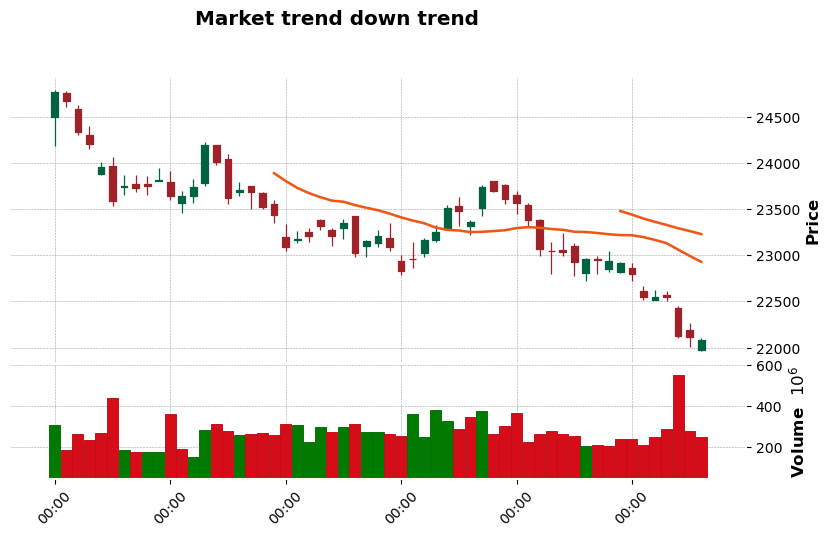

In [22]:
down_trend.rename(columns={'Shares Traded':'Volume'}, inplace=True)
mp.plot(down_trend,type='candle',volume =True,mav=(20,50,200),style ='charles',figratio=(16,9),title ='Market trend down trend' )

# side trend dataset

In [23]:
side_trend

,Date,Open,High,Low,Close,Shares Traded,Turnover (₹ Cr)
0,10-OCT-2025,25167.65,25330.75,25156.85,25285.35,232943306,21749.23
1,09-OCT-2025,25074.30,25199.25,25024.30,25181.80,286253252,22617.86
2,08-OCT-2025,25079.75,25192.50,25008.50,25046.15,225967495,21701.19
3,07-OCT-2025,25085.30,25220.90,25076.30,25108.30,286833765,26176.23
4,06-OCT-2025,24916.55,25095.95,24881.65,25077.65,271953070,25160.76
...,...,...,...,...,...,...,...
66,07-JUL-2025,25450.45,25489.80,25407.25,25461.30,196051345,16923.26
67,04-JUL-2025,25428.85,25470.25,25331.65,25461.00,193511595,19101.33
68,03-JUL-2025,25505.10,25587.50,25384.35,25405.30,293428797,24531.70
69,02-JUL-2025,25588.30,25608.10,25378.75,25453.40,309828013,26681.66


In [24]:
side_trend.columns = side_trend.columns.str.strip()

In [25]:
side_trend['Date'] = pd.to_datetime(side_trend['Date'])
side_trend = side_trend.sort_values('Date')

C:\Users\Harsh\AppData\Local\Temp\ipykernel_18044\1816375240.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  side_trend['Date'] = pd.to_datetime(side_trend['Date'])


In [26]:
side_trend = side_trend.sort_values('Date',ascending=True).reset_index(drop = True)
side_trend

,Date,Open,High,Low,Close,Shares Traded,Turnover (₹ Cr)
0,2025-07-01,25551.35,25593.40,25501.80,25541.80,260669106,23921.02
1,2025-07-02,25588.30,25608.10,25378.75,25453.40,309828013,26681.66
2,2025-07-03,25505.10,25587.50,25384.35,25405.30,293428797,24531.70
3,2025-07-04,25428.85,25470.25,25331.65,25461.00,193511595,19101.33
4,2025-07-07,25450.45,25489.80,25407.25,25461.30,196051345,16923.26
...,...,...,...,...,...,...,...
66,2025-10-06,24916.55,25095.95,24881.65,25077.65,271953070,25160.76
67,2025-10-07,25085.30,25220.90,25076.30,25108.30,286833765,26176.23
68,2025-10-08,25079.75,25192.50,25008.50,25046.15,225967495,21701.19
69,2025-10-09,25074.30,25199.25,25024.30,25181.80,286253252,22617.86


<Axes: >

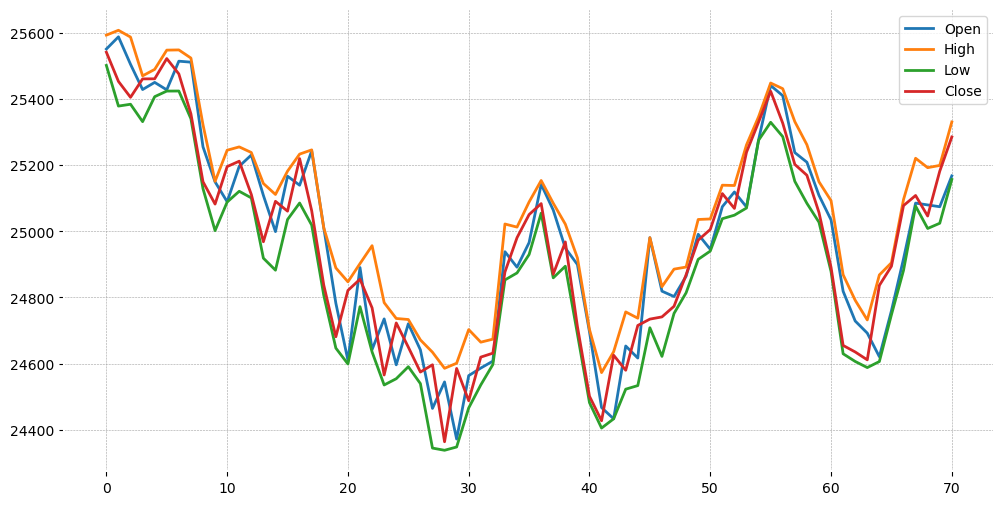

In [27]:
side_trend[['Open','High','Low','Close']].plot(figsize=(12,6))

<Axes: >

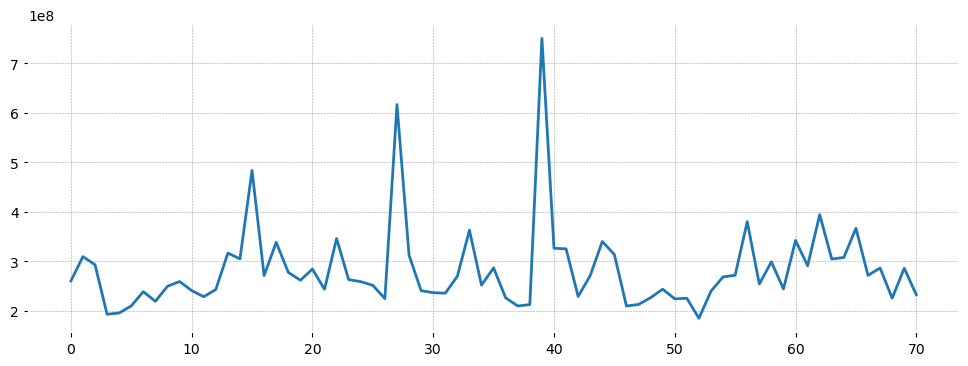

In [28]:
side_trend['Shares Traded'].plot(figsize =(12,4))

<Axes: >

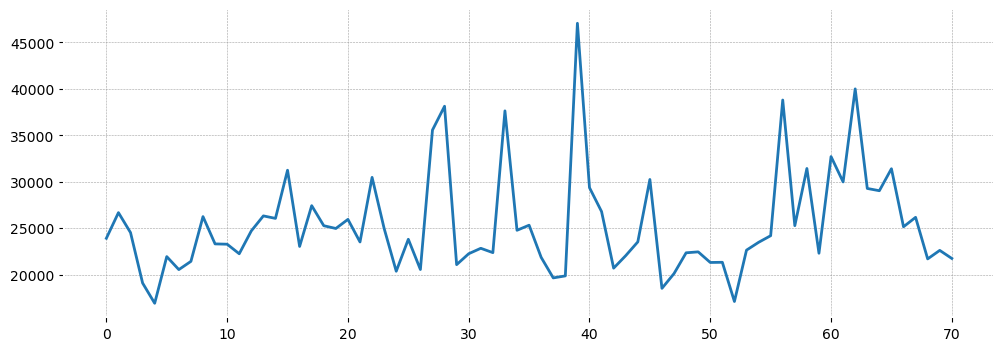

In [29]:
side_trend['Turnover (₹ Cr)'].plot(figsize =(12,4))

In [30]:
side_trend.index = pd.to_datetime(side_trend.index)
#Force convert to DatetimeIndex

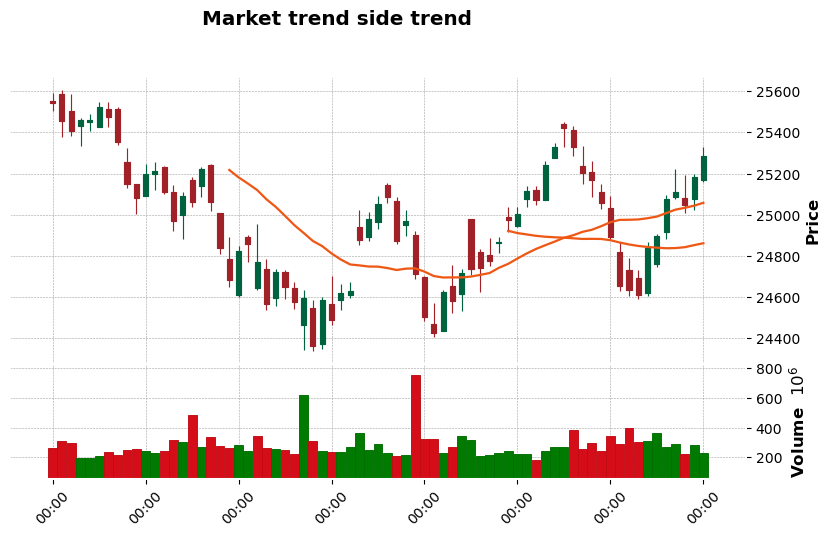

In [31]:
side_trend.rename(columns={'Shares Traded':'Volume'}, inplace=True)
mp.plot(side_trend,type='candle',volume =True,mav=(20,50,200),style ='charles',figratio=(16,9),title ='Market trend side trend')

In [32]:
data= pd.read_csv('NIFTY50_1995_to_Feb_2026.csv')

In [33]:
up_trend['Trend']='Up'
down_trend['Trend']='down'
side_trend['Trend']='side'

In [34]:
dataset = pd.concat([down_trend,up_trend,side_trend])

In [35]:
dataset

,Date,Open,High,Low,Close,Volume,Turnover (₹ Cr),Trend
1970-01-01 00:00:00.000000000,2024-12-13,24498.35,24792.30,24180.80,24768.30,310080852,30429.73,down
1970-01-01 00:00:00.000000001,2024-12-16,24753.40,24781.25,24601.75,24668.25,187551629,18608.23,down
1970-01-01 00:00:00.000000002,2024-12-17,24584.80,24624.10,24303.45,24336.00,264881033,26765.16,down
1970-01-01 00:00:00.000000003,2024-12-18,24297.95,24394.45,24149.85,24198.85,235346534,23315.92,down
1970-01-01 00:00:00.000000004,2024-12-19,23877.15,24004.90,23870.30,23951.70,271128027,27815.23,down
...,...,...,...,...,...,...,...,...
1970-01-01 00:00:00.000000066,2025-10-06,24916.55,25095.95,24881.65,25077.65,271953070,25160.76,side
1970-01-01 00:00:00.000000067,2025-10-07,25085.30,25220.90,25076.30,25108.30,286833765,26176.23,side
1970-01-01 00:00:00.000000068,2025-10-08,25079.75,25192.50,25008.50,25046.15,225967495,21701.19,side
1970-01-01 00:00:00.000000069,2025-10-09,25074.30,25199.25,25024.30,25181.80,286253252,22617.86,side


In [36]:
dataset = dataset.reset_index(drop=True)
dataset

,Date,Open,High,Low,Close,Volume,Turnover (₹ Cr),Trend
0,2024-12-13,24498.35,24792.30,24180.80,24768.30,310080852,30429.73,down
1,2024-12-16,24753.40,24781.25,24601.75,24668.25,187551629,18608.23,down
2,2024-12-17,24584.80,24624.10,24303.45,24336.00,264881033,26765.16,down
3,2024-12-18,24297.95,24394.45,24149.85,24198.85,235346534,23315.92,down
4,2024-12-19,23877.15,24004.90,23870.30,23951.70,271128027,27815.23,down
...,...,...,...,...,...,...,...,...
195,2025-10-06,24916.55,25095.95,24881.65,25077.65,271953070,25160.76,side
196,2025-10-07,25085.30,25220.90,25076.30,25108.30,286833765,26176.23,side
197,2025-10-08,25079.75,25192.50,25008.50,25046.15,225967495,21701.19,side
198,2025-10-09,25074.30,25199.25,25024.30,25181.80,286253252,22617.86,side


In [37]:
data

,Date,Close,High,Low,Open,Volume,Ticker,Daily_Return_%,MA_50,MA_200
0,NaN,^NSEI,^NSEI,^NSEI,^NSEI,^NSEI,NaN,NaN,NaN,NaN
1,2007-09-17,4494.64990234375,4549.0498046875,4482.85009765625,4518.4501953125,0,^NSEI,NaN,NaN,NaN
2,2007-09-18,4546.2001953125,4551.7998046875,4481.5498046875,4494.10009765625,0,^NSEI,1.146926,NaN,NaN
3,2007-09-19,4732.35009765625,4739.0,4550.25,4550.25,0,^NSEI,4.094626,NaN,NaN
4,2007-09-20,4747.5498046875,4760.85009765625,4721.14990234375,4734.85009765625,0,^NSEI,0.321187,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
4518,2026-02-16,25682.75,25697.0,25372.69921875,25423.599609375,275800,^NSEI,0.830943,25789.227148,25297.195088
4519,2026-02-17,25725.400390625,25764.400390625,25570.30078125,25637.94921875,344100,^NSEI,0.166066,25783.060156,25304.151094
4520,2026-02-18,25819.349609375,25828.05078125,25645.150390625,25752.650390625,310200,^NSEI,0.365200,25775.718164,25311.514346
4521,2026-02-19,25454.349609375,25885.30078125,25388.75,25873.349609375,298200,^NSEI,-1.413668,25765.594141,25316.480342


In [38]:
data = data.drop(0)

In [39]:
data.duplicated()

1       False
2       False
3       False
4       False
5       False
        ...  
4518    False
4519    False
4520    False
4521    False
4522    False
Length: 4522, dtype: bool

In [40]:
data

,Date,Close,High,Low,Open,Volume,Ticker,Daily_Return_%,MA_50,MA_200
1,2007-09-17,4494.64990234375,4549.0498046875,4482.85009765625,4518.4501953125,0,^NSEI,NaN,NaN,NaN
2,2007-09-18,4546.2001953125,4551.7998046875,4481.5498046875,4494.10009765625,0,^NSEI,1.146926,NaN,NaN
3,2007-09-19,4732.35009765625,4739.0,4550.25,4550.25,0,^NSEI,4.094626,NaN,NaN
4,2007-09-20,4747.5498046875,4760.85009765625,4721.14990234375,4734.85009765625,0,^NSEI,0.321187,NaN,NaN
5,2007-09-21,4837.5498046875,4855.7001953125,4733.7001953125,4752.9501953125,0,^NSEI,1.895715,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
4518,2026-02-16,25682.75,25697.0,25372.69921875,25423.599609375,275800,^NSEI,0.830943,25789.227148,25297.195088
4519,2026-02-17,25725.400390625,25764.400390625,25570.30078125,25637.94921875,344100,^NSEI,0.166066,25783.060156,25304.151094
4520,2026-02-18,25819.349609375,25828.05078125,25645.150390625,25752.650390625,310200,^NSEI,0.365200,25775.718164,25311.514346
4521,2026-02-19,25454.349609375,25885.30078125,25388.75,25873.349609375,298200,^NSEI,-1.413668,25765.594141,25316.480342


In [41]:
data.isna().sum()

Date                0
Close               0
High                0
Low                 0
Open                0
Volume              0
Ticker              0
Daily_Return_%      1
MA_50              49
MA_200            199
dtype: int64

In [42]:
data.describe()

,Daily_Return_%,MA_50,MA_200
count,4521.000000,4473.000000,4323.000000
mean,0.046935,10979.913810,10823.550213
std,1.301451,6360.714781,6103.104091
min,-12.980466,2784.175981,3369.808739
25%,-0.521096,5714.385986,5677.921379
50%,0.062461,8702.336953,8696.731248
75%,0.652062,15865.322988,15464.105984
max,17.744066,25971.740117,25322.438594


In [43]:
data.drop(columns =['Ticker'],inplace = True)

In [44]:
data = data.dropna()

In [45]:
data =data.reset_index(drop=True)

In [46]:
data.shape

(4323, 9)

In [47]:
data[['Close','High','Low','Open']] = data[['Close','High','Low','Open']].round(2)
data[['MA_50','MA_200']] = data[['MA_50','MA_200']].round(2)
data['Daily_Return_%'] = data['Daily_Return_%'].round(3)

In [48]:
data.head()

,Date,Close,High,Low,Open,Volume,Daily_Return_%,MA_50,MA_200
0,2008-07-07,4030.0,4114.5,4002.0,4002.0,0,0.349,4696.75,5210.72
1,2008-07-08,3988.550048828125,4028.699951171875,3896.050048828125,4028.699951171875,0,-1.029,4674.28,5208.19
2,2008-07-09,4157.10009765625,4169.39990234375,3990.89990234375,3990.89990234375,0,4.226,4655.63,5206.24
3,2008-07-10,4162.2001953125,4187.9501953125,4110.39990234375,4155.64990234375,0,0.123,4634.97,5203.39
4,2008-07-11,4049.0,4215.5,4014.449951171875,4166.0,0,-2.720,4612.63,5199.90


In [49]:
dataset

,Date,Open,High,Low,Close,Volume,Turnover (₹ Cr),Trend
0,2024-12-13,24498.35,24792.30,24180.80,24768.30,310080852,30429.73,down
1,2024-12-16,24753.40,24781.25,24601.75,24668.25,187551629,18608.23,down
2,2024-12-17,24584.80,24624.10,24303.45,24336.00,264881033,26765.16,down
3,2024-12-18,24297.95,24394.45,24149.85,24198.85,235346534,23315.92,down
4,2024-12-19,23877.15,24004.90,23870.30,23951.70,271128027,27815.23,down
...,...,...,...,...,...,...,...,...
195,2025-10-06,24916.55,25095.95,24881.65,25077.65,271953070,25160.76,side
196,2025-10-07,25085.30,25220.90,25076.30,25108.30,286833765,26176.23,side
197,2025-10-08,25079.75,25192.50,25008.50,25046.15,225967495,21701.19,side
198,2025-10-09,25074.30,25199.25,25024.30,25181.80,286253252,22617.86,side


In [50]:
data['Volume'].unique()

array(['0', '130900', '129000', ..., '344100', '310200', '298200'],
      dtype=object)

In [51]:
data['Volume'].value_counts()

Volume
0         1134
187600       7
230200       6
219500       6
232600       6
          ... 
412100       1
350700       1
398100       1
373000       1
298200       1
Name: count, Length: 2228, dtype: int64

In [52]:
data

,Date,Close,High,Low,Open,Volume,Daily_Return_%,MA_50,MA_200
0,2008-07-07,4030.0,4114.5,4002.0,4002.0,0,0.349,4696.75,5210.72
1,2008-07-08,3988.550048828125,4028.699951171875,3896.050048828125,4028.699951171875,0,-1.029,4674.28,5208.19
2,2008-07-09,4157.10009765625,4169.39990234375,3990.89990234375,3990.89990234375,0,4.226,4655.63,5206.24
3,2008-07-10,4162.2001953125,4187.9501953125,4110.39990234375,4155.64990234375,0,0.123,4634.97,5203.39
4,2008-07-11,4049.0,4215.5,4014.449951171875,4166.0,0,-2.720,4612.63,5199.90
...,...,...,...,...,...,...,...,...,...
4318,2026-02-16,25682.75,25697.0,25372.69921875,25423.599609375,275800,0.831,25789.23,25297.20
4319,2026-02-17,25725.400390625,25764.400390625,25570.30078125,25637.94921875,344100,0.166,25783.06,25304.15
4320,2026-02-18,25819.349609375,25828.05078125,25645.150390625,25752.650390625,310200,0.365,25775.72,25311.51
4321,2026-02-19,25454.349609375,25885.30078125,25388.75,25873.349609375,298200,-1.414,25765.59,25316.48


In [53]:
print(data['Volume'].dtype)

object


In [54]:
data['Volume'] = pd.to_numeric(data['Volume'], errors='coerce')
#Convert to numeric

In [55]:
data['Volume'] = data['Volume'].replace(0, np.nan)

In [56]:
data['Volume'] = data['Volume'].interpolate()

#The interpolate() function is commonly used in data processing to fill in missing values or estimate intermediate values 
#between known data points. In Python, it is widely available in libraries like Pandas and NumPy for numerical and time series 
#data.

In [57]:
data['Volume'] = data['Volume'].bfill()

In [58]:
data

,Date,Close,High,Low,Open,Volume,Daily_Return_%,MA_50,MA_200
0,2008-07-07,4030.0,4114.5,4002.0,4002.0,130900.0,0.349,4696.75,5210.72
1,2008-07-08,3988.550048828125,4028.699951171875,3896.050048828125,4028.699951171875,130900.0,-1.029,4674.28,5208.19
2,2008-07-09,4157.10009765625,4169.39990234375,3990.89990234375,3990.89990234375,130900.0,4.226,4655.63,5206.24
3,2008-07-10,4162.2001953125,4187.9501953125,4110.39990234375,4155.64990234375,130900.0,0.123,4634.97,5203.39
4,2008-07-11,4049.0,4215.5,4014.449951171875,4166.0,130900.0,-2.720,4612.63,5199.90
...,...,...,...,...,...,...,...,...,...
4318,2026-02-16,25682.75,25697.0,25372.69921875,25423.599609375,275800.0,0.831,25789.23,25297.20
4319,2026-02-17,25725.400390625,25764.400390625,25570.30078125,25637.94921875,344100.0,0.166,25783.06,25304.15
4320,2026-02-18,25819.349609375,25828.05078125,25645.150390625,25752.650390625,310200.0,0.365,25775.72,25311.51
4321,2026-02-19,25454.349609375,25885.30078125,25388.75,25873.349609375,298200.0,-1.414,25765.59,25316.48


In [59]:
dataset['Daily_Return_%'] = dataset['Close'].pct_change() * 100

In [60]:
dataset['MA_50'] = dataset['Close'].rolling(window=50).mean()

In [61]:
dataset['MA_200'] = dataset['Close'].rolling(window=100).mean()

In [62]:
dataset

,Date,Open,High,Low,Close,Volume,Turnover (₹ Cr),Trend,Daily_Return_%,MA_50,MA_200
0,2024-12-13,24498.35,24792.30,24180.80,24768.30,310080852,30429.73,down,NaN,NaN,NaN
1,2024-12-16,24753.40,24781.25,24601.75,24668.25,187551629,18608.23,down,-0.403944,NaN,NaN
2,2024-12-17,24584.80,24624.10,24303.45,24336.00,264881033,26765.16,down,-1.346873,NaN,NaN
3,2024-12-18,24297.95,24394.45,24149.85,24198.85,235346534,23315.92,down,-0.563568,NaN,NaN
4,2024-12-19,23877.15,24004.90,23870.30,23951.70,271128027,27815.23,down,-1.021330,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
195,2025-10-06,24916.55,25095.95,24881.65,25077.65,271953070,25160.76,side,0.736716,24836.710,24939.7635
196,2025-10-07,25085.30,25220.90,25076.30,25108.30,286833765,26176.23,side,0.122220,24837.634,24944.1775
197,2025-10-08,25079.75,25192.50,25008.50,25046.15,225967495,21701.19,side,-0.247528,24841.817,24944.0180
198,2025-10-09,25074.30,25199.25,25024.30,25181.80,286253252,22617.86,side,0.541600,24851.835,24945.6380


In [63]:
dataset.isna().sum()

Date                0
Open                0
High                0
Low                 0
Close               0
Volume              0
Turnover (₹ Cr)     0
Trend               0
Daily_Return_%      1
MA_50              49
MA_200             99
dtype: int64

In [64]:
dataset['MA_50'] = dataset['MA_50'].bfill()

In [65]:
dataset['Daily_Return_%'] = dataset['Daily_Return_%'].bfill()

In [66]:
dataset = dataset.drop('MA_200',axis=True)

In [67]:
dataset

,Date,Open,High,Low,Close,Volume,Turnover (₹ Cr),Trend,Daily_Return_%,MA_50
0,2024-12-13,24498.35,24792.30,24180.80,24768.30,310080852,30429.73,down,-0.403944,23478.486
1,2024-12-16,24753.40,24781.25,24601.75,24668.25,187551629,18608.23,down,-0.403944,23478.486
2,2024-12-17,24584.80,24624.10,24303.45,24336.00,264881033,26765.16,down,-1.346873,23478.486
3,2024-12-18,24297.95,24394.45,24149.85,24198.85,235346534,23315.92,down,-0.563568,23478.486
4,2024-12-19,23877.15,24004.90,23870.30,23951.70,271128027,27815.23,down,-1.021330,23478.486
...,...,...,...,...,...,...,...,...,...,...
195,2025-10-06,24916.55,25095.95,24881.65,25077.65,271953070,25160.76,side,0.736716,24836.710
196,2025-10-07,25085.30,25220.90,25076.30,25108.30,286833765,26176.23,side,0.122220,24837.634
197,2025-10-08,25079.75,25192.50,25008.50,25046.15,225967495,21701.19,side,-0.247528,24841.817
198,2025-10-09,25074.30,25199.25,25024.30,25181.80,286253252,22617.86,side,0.541600,24851.835


# on data 

In [68]:
from scipy.stats import linregress

import warnings
warnings.filterwarnings('ignore')

In [69]:
df_long = data        # 2008–2026 dataset
df_short = dataset    # 2025 dataset

In [70]:
print(df_long.shape, df_short.shape)
print("Data Ready")

(4323, 9) (200, 10)
Data Ready


In [71]:
#Force-clean numeric columns (with commas/spaces handling)
def add_features(df):
    df = df.copy()

    df['Close'] = pd.to_numeric(df['Close'], errors='coerce')

    df['MA_50'] = df['Close'].rolling(50).mean()
    df['Daily_Return'] = df['Close'].pct_change() * 100
    df['Volatility_20'] = df['Daily_Return'].rolling(20).std()

    df['diff_%'] = (df['Close'] - df['MA_50']) / df['MA_50'] * 100

    threshold = 2.5

    condition_up = df['diff_%'] > threshold
    condition_down = df['diff_%'] < -threshold

    df['Trend'] = np.where(condition_up, 'Uptrend',
                   np.where(condition_down, 'Downtrend', 'Sideways'))

    return df

In [72]:
df_long = df_long.dropna(subset=['Close'])
df_short = df_short.dropna(subset=['Close'])

In [73]:
print(df_long['Close'].dtype)
print(df_short['Close'].dtype)

object
float64


In [74]:
df_long = add_features(df_long)
df_short = add_features(df_short)

In [75]:
def trend_slope(df):
    x = np.arange(len(df))
    y = df['Close'].values

    slope, intercept, r_value, p_value, std_err = linregress(x, y)

    return {
        "daily_slope": slope,
        "annual_slope": slope * 252,
        "r2": r_value**2
    }

In [76]:
long_trend = trend_slope(df_long)
short_trend = trend_slope(df_short)


In [77]:
print("\n=== Trend Analysis ===")
print("Long Term:", long_trend)
print("Short Term:", short_trend)


=== Trend Analysis ===
Long Term: {'daily_slope': 4.869335337440713, 'annual_slope': 1227.0725050350597, 'r2': 0.884492120511956}
Short Term: {'daily_slope': 11.370153828845716, 'annual_slope': 2865.2787648691206, 'r2': 0.5361500526174415}


In [78]:
def adf_test(series, name):
    result = adfuller(series.dropna())

    print(f"\nADF Test: {name}")
    print(f"ADF Statistic : {result[0]:.4f}")
    print(f"p-value       : {result[1]:.4f}")

    if result[1] < 0.05:
        print("Conclusion    : Stationary")
    else:
        print("Conclusion    : Non-Stationary")
        
#The Augmented Dickey-Fuller (ADF) test is a statistical test used to determine whether a given time series is stationary or not.
#A time series is considered stationary if it has no trend, exhibits constant variance over time, and has a constant 
#autocorrelation structure over time.        

In [79]:
adf_test(df_long['Close'], "Long-term")
adf_test(df_short['Close'], "Short-term")


ADF Test: Long-term
ADF Statistic : 0.9698
p-value       : 0.9939
Conclusion    : Non-Stationary

ADF Test: Short-term
ADF Statistic : -1.3557
p-value       : 0.6033
Conclusion    : Non-Stationary


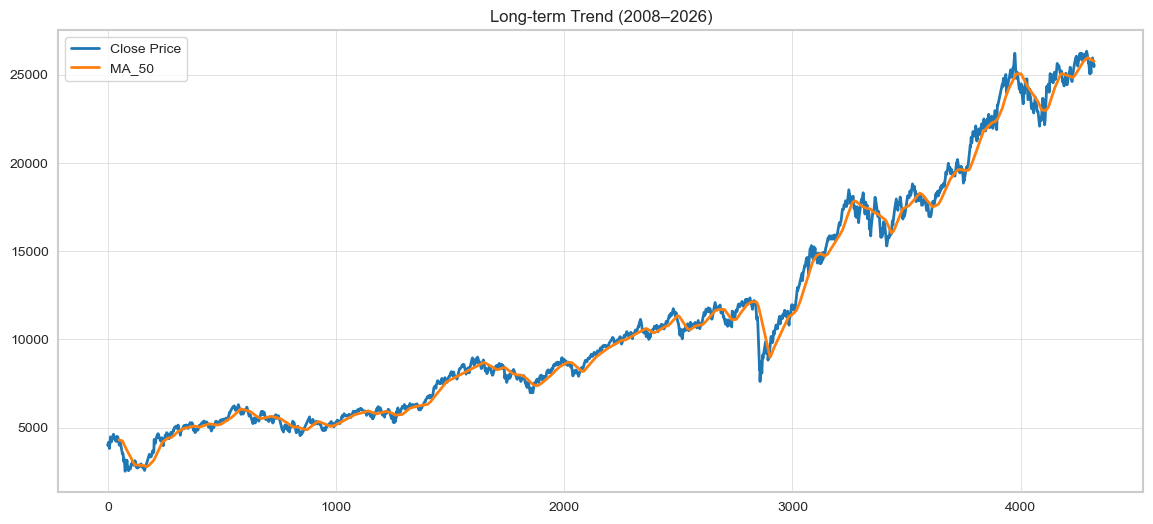

In [80]:
sns.set_style("whitegrid")

# Long-term
plt.figure(figsize=(14,6))
plt.plot(df_long['Close'], label='Close Price')
plt.plot(df_long['MA_50'], label='MA_50')
plt.title("Long-term Trend (2008–2026)")
plt.legend()
plt.savefig("long_term_trend.png", dpi=300)
plt.show()

#DPI stands for "Dots Per Inch," a measure of resolution in printing, imaging, and mouse sensitivity.

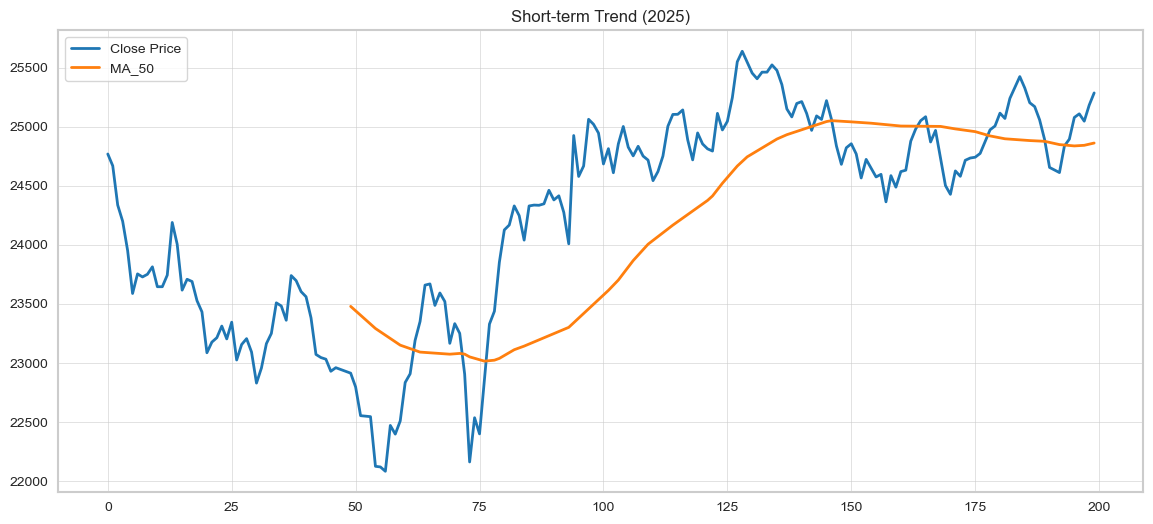

In [81]:
# Short-term
plt.figure(figsize=(14,6))
plt.plot(df_short['Close'], label='Close Price')
plt.plot(df_short['MA_50'], label='MA_50')
plt.title("Short-term Trend (2025)")
plt.legend()
plt.savefig("short_term_trend.png", dpi=300)
plt.show()

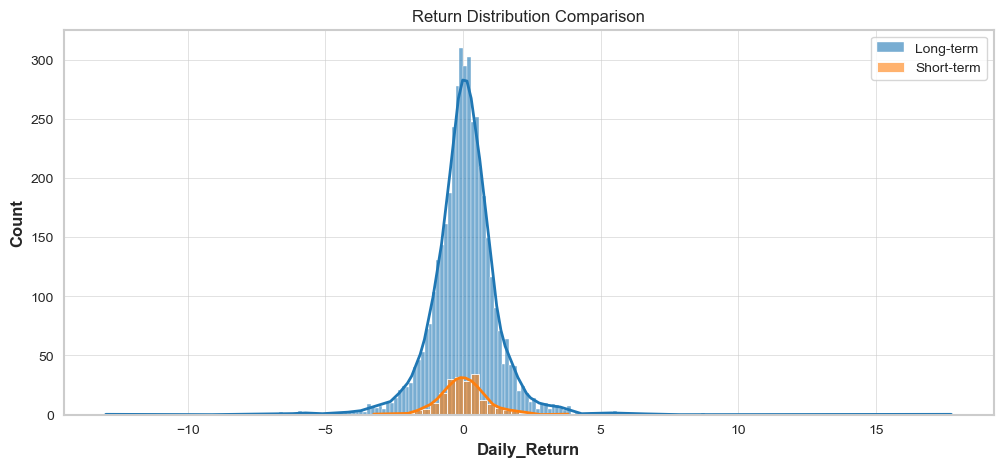

In [82]:
# Returns Distribution
plt.figure(figsize=(12,5))
sns.histplot(df_long['Daily_Return'], kde=True, label='Long-term', alpha=0.6)
sns.histplot(df_short['Daily_Return'], kde=True, label='Short-term', alpha=0.6)
plt.legend()
plt.title("Return Distribution Comparison")
plt.savefig("returns.png", dpi=300)
plt.show()

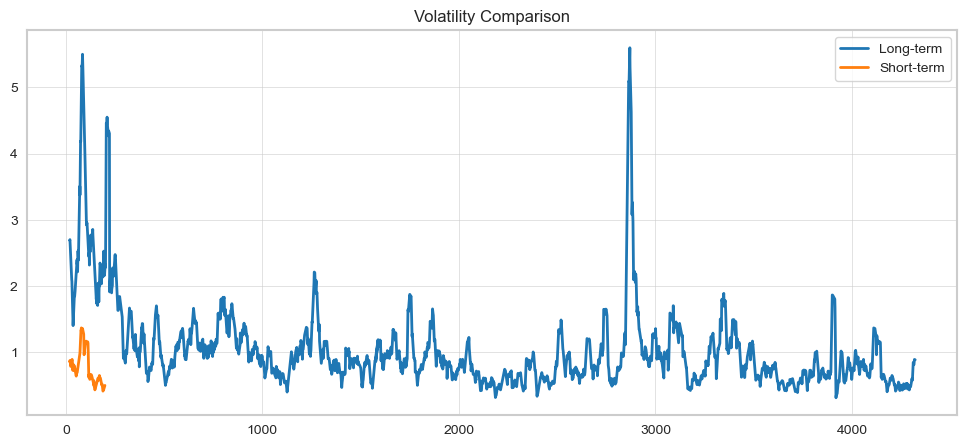

In [83]:
# Volatility
plt.figure(figsize=(12,5))
df_long['Volatility_20'].plot(label='Long-term')
df_short['Volatility_20'].plot(label='Short-term')
plt.legend()
plt.title("Volatility Comparison")
plt.savefig("volatility.png", dpi=300)
plt.show()

In [84]:
summary = pd.DataFrame({
    "Metric": ["Mean Return", "Volatility", "Max Price", "Min Price"],
    "Long-term": [
        df_long['Daily_Return'].mean(),
        df_long['Daily_Return'].std(),
        df_long['Close'].max(),
        df_long['Close'].min()
    ],
    "Short-term": [
        df_short['Daily_Return'].mean(),
        df_short['Daily_Return'].std(),
        df_short['Close'].max(),
        df_short['Close'].min()
    ]
})

print("\n=== Summary ===")
print(summary)

summary.to_csv("summary_table.csv", index=False)


=== Summary ===
        Metric     Long-term    Short-term
0  Mean Return      0.050429      0.013697
1   Volatility      1.238468      0.817031
2    Max Price  26328.550781  25637.800000
3    Min Price   2524.199951  22082.650000


In [85]:
trend_dist = pd.DataFrame({
    "Long-term (%)": df_long['Trend'].value_counts(normalize=True) * 100,
    "Short-term (%)": df_short['Trend'].value_counts(normalize=True) * 100
}).round(2)

print("\nTrend Distribution")
print(trend_dist)

trend_dist.to_csv("trend_distribution.csv")



Trend Distribution
           Long-term (%)  Short-term (%)
Trend                                   
Sideways           43.70            70.0
Uptrend            38.21            23.5
Downtrend          18.09             6.5


In [86]:
 print(df_long.head())

         Date        Close               High                Low  \
0  2008-07-07  4030.000000             4114.5             4002.0   
1  2008-07-08  3988.550049  4028.699951171875  3896.050048828125   
2  2008-07-09  4157.100098   4169.39990234375   3990.89990234375   
3  2008-07-10  4162.200195    4187.9501953125   4110.39990234375   
4  2008-07-11  4049.000000             4215.5  4014.449951171875   

                Open    Volume  Daily_Return_%  MA_50   MA_200  Daily_Return  \
0             4002.0  130900.0           0.349    NaN  5210.72           NaN   
1  4028.699951171875  130900.0          -1.029    NaN  5208.19     -1.028535   
2   3990.89990234375  130900.0           4.226    NaN  5206.24      4.225848   
3   4155.64990234375  130900.0           0.123    NaN  5203.39      0.122684   
4             4166.0  130900.0          -2.720    NaN  5199.90     -2.719720   

   Volatility_20  diff_%     Trend  
0            NaN     NaN  Sideways  
1            NaN     NaN  Sideways  

In [87]:
print(df_long['Trend'].value_counts())

Trend
Sideways     1889
Uptrend      1652
Downtrend     782
Name: count, dtype: int64


In [88]:
print(df_short['Trend'].value_counts())

Trend
Sideways     140
Uptrend       47
Downtrend     13
Name: count, dtype: int64


In [89]:
dataset['Trend'].value_counts()

Trend
Up      72
side    71
down    57
Name: count, dtype: int64

In [90]:
df_long['diff_%'] = (df_long['Close'] - df_long['MA_50']) / df_long['MA_50'] * 100

print(df_long['diff_%'].describe())

count    4274.000000
mean        1.087508
std         5.139435
min       -35.792118
25%        -1.426112
50%         1.515457
75%         3.729802
max        35.592841
Name: diff_%, dtype: float64


In [91]:
threshold = df_long['diff_%'].std() / 100 

In [92]:
df_long = add_features(df_long)
df_short = add_features(df_short)

print(df_long['Trend'].value_counts())
print(df_short['Trend'].value_counts())

Trend
Sideways     1889
Uptrend      1652
Downtrend     782
Name: count, dtype: int64
Trend
Sideways     140
Uptrend       47
Downtrend     13
Name: count, dtype: int64


In [93]:
print(df_long[['Close','MA_50','diff_%']].tail(20))

             Close         MA_50    diff_%
4303  25048.650391  25924.911172 -3.379995
4304  25175.400391  25910.836172 -2.838333
4305  25342.750000  25899.490156 -2.149618
4306  25418.900391  25887.599180 -1.810515
4307  25320.650391  25875.811172 -2.145482
4308  25088.400391  25856.526172 -2.970723
4309  25727.550781  25847.234180 -0.463041
4310  25776.000000  25841.391172 -0.253048
4311  25642.800781  25835.057187 -0.744169
4312  25693.699219  25831.235156 -0.532440
4313  25867.300781  25824.475156  0.165833
4314  25935.150391  25818.867148  0.450381
4315  25953.849609  25813.885156  0.542206
4316  25807.199219  25806.514141  0.002655
4317  25471.099609  25795.292148 -1.256790
4318  25682.750000  25789.227148 -0.412875
4319  25725.400391  25783.060156 -0.223634
4320  25819.349609  25775.718164  0.169273
4321  25454.349609  25765.594141 -1.207985
4322  25571.250000  25760.226133 -0.733597


In [94]:
print(df_long['Trend'].value_counts(normalize=True)*100)
print(df_short['Trend'].value_counts(normalize=True)*100)

Trend
Sideways     43.696507
Uptrend      38.214203
Downtrend    18.089290
Name: proportion, dtype: float64
Trend
Sideways     70.0
Uptrend      23.5
Downtrend     6.5
Name: proportion, dtype: float64


In [95]:
print(summary)
print(trend_dist)

        Metric     Long-term    Short-term
0  Mean Return      0.050429      0.013697
1   Volatility      1.238468      0.817031
2    Max Price  26328.550781  25637.800000
3    Min Price   2524.199951  22082.650000
           Long-term (%)  Short-term (%)
Trend                                   
Sideways           43.70            70.0
Uptrend            38.21            23.5
Downtrend          18.09             6.5


# prediction

In [101]:
# =====================  ML PREDICTION MODEL =====================
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression

# Optional: XGBoost (better performance)
try:
    from xgboost import XGBRegressor
    xgb_available = True
except:
    xgb_available = False

In [112]:
# ------------------- Prepare Features -------------------
def prepare_ml_data(df):
    df_ml = df.copy()

    # Lag features
    for i in range(1, 6):
        df_ml[f'Lag_{i}'] = df_ml['Close'].shift(i)

    # Rolling features
    df_ml['MA_10'] = df_ml['Close'].rolling(10).mean()
    df_ml['MA_20'] = df_ml['Close'].rolling(20).mean()
    df_ml['EMA_20'] = df_ml['Close'].ewm(span=20).mean()

    # Returns & volatility
    df_ml['Return'] = df_ml['Close'].pct_change()
    df_ml['Volatility'] = df_ml['Return'].rolling(10).std()

    # Time feature (VERY IMPORTANT)
    df_ml['Time_Index'] = np.arange(len(df_ml))

    df_ml = df_ml.dropna()

    features = [col for col in df_ml.columns if col not in ['Close', 'Trend']]

    X = df_ml[features]
    y = df_ml['Close']

    return X, y, df_ml

In [113]:
# ------------------- Time-Series Split -------------------
split = int(len(X) * 0.8)

X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

In [114]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [115]:
# ------------------- 1. Linear Regression -------------------
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)


In [116]:
# ------------------- 2. XGBoost Model -------------------
if xgb_available:
    xgb = XGBRegressor(n_estimators=500,learning_rate=0.03,max_depth=8,subsample=0.8,colsample_bytree=0.8,random_state=42)
    xgb.fit(X_train, y_train)
    y_pred_xgb = xgb.predict(X_test)

In [117]:
# ------------------- Evaluation -------------------
def evaluate_model(name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    print(f"\n{name} Performance:")
    print(f"RMSE : {rmse:.2f}")
    print(f"R²   : {r2:.4f}")

evaluate_model("Linear Regression", y_test, y_pred_lr)

if xgb_available:
    evaluate_model("XGBoost", y_test, y_pred_xgb)


Linear Regression Performance:
RMSE : 170.32
R²   : 0.9966

XGBoost Performance:
RMSE : 4975.40
R²   : -1.8712


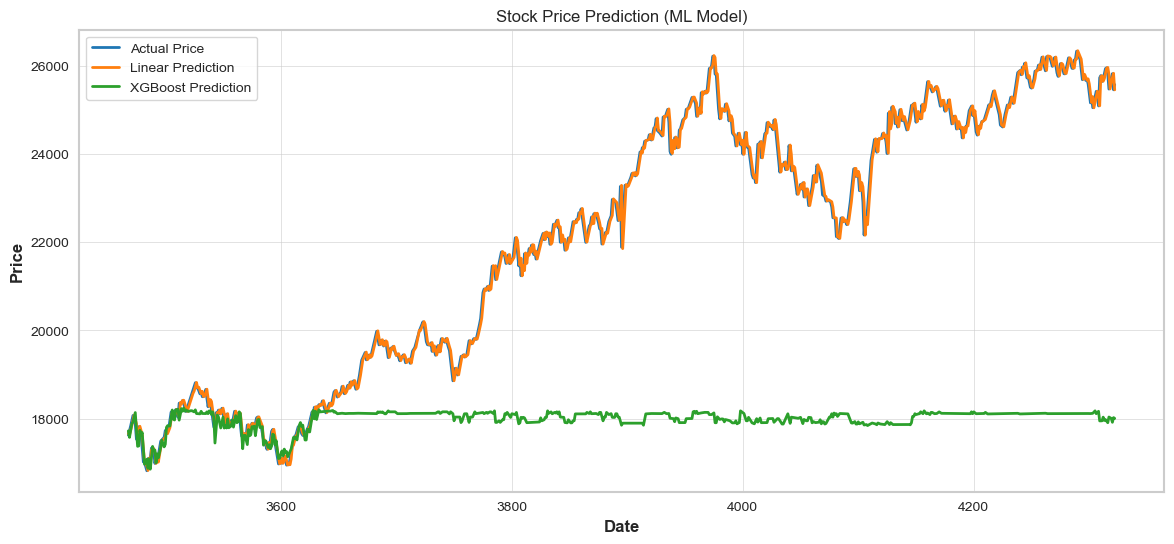

In [118]:
# ------------------- Prediction Plot -------------------
plt.figure(figsize=(14,6))

plt.plot(y_test.index, y_test.values, label='Actual Price', linewidth=2)
plt.plot(y_test.index, y_pred_lr, label='Linear Prediction')

if xgb_available:
    plt.plot(y_test.index, y_pred_xgb, label='XGBoost Prediction')

plt.title("Stock Price Prediction (ML Model)")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()

plt.savefig("ml_prediction.png", dpi=300)
plt.show()

In [119]:
results = pd.DataFrame({
    "Date": y_test.index,
    "Actual": y_test.values,
    "Linear_Pred": y_pred_lr
})

if xgb_available:
    results["XGB_Pred"] = y_pred_xgb

results.to_csv("ml_predictions.csv", index=False)

print("\nML Model Completed!")


ML Model Completed!


# undersampling

In [122]:
normal = data
short = dataset

In [123]:
print(normal.shape, short.shape)
print("Data Ready")

(4323, 9) (200, 10)
Data Ready


In [125]:
#normal_sample=normal.sample(n=200)
normal_sample = normal.iloc[::len(normal)//200]

In [126]:
def add_features(df):
    df = df.copy()

    df['Close'] = pd.to_numeric(df['Close'], errors='coerce')

    df['MA_50'] = df['Close'].rolling(50).mean()
    df['Daily_Return'] = df['Close'].pct_change() * 100
    df['Volatility_20'] = df['Daily_Return'].rolling(20).std()

    # NEW (important)
    df['Time_Index'] = np.arange(len(df))

    df['diff_%'] = (df['Close'] - df['MA_50']) / df['MA_50'] * 100

    threshold = 2.5

    condition_up = df['diff_%'] > threshold
    condition_down = df['diff_%'] < -threshold

    df['Trend'] = np.where(condition_up, 'Uptrend',
                   np.where(condition_down, 'Downtrend', 'Sideways'))

    return df

In [129]:
normal_sample['Close'] = pd.to_numeric(normal_sample['Close'], errors='coerce')
short['Close'] = pd.to_numeric(short['Close'], errors='coerce')

In [130]:
normal_sample= normal_sample.dropna(subset=['Close'])
short = short.dropna(subset=['Close'])

In [131]:
print(normal_sample['Close'].dtype)
print(short['Close'].dtype)

float64
float64


In [132]:
normal_sample= add_features(normal_sample)
short = add_features(short)

In [133]:
def trend_slope(df):
    x = np.arange(len(df))
    y = df['Close'].values

    slope, intercept, r_value, p_value, std_err = linregress(x, y)

    return {
        "daily_slope": slope,
        "annual_slope": slope * 252,
        "r2": r_value**2
    }

In [136]:
long_trend = trend_slope(normal_sample)
short_trend = trend_slope(short)


In [137]:
# undersampling
print("\n=== Trend Analysis ===")
print("Long Term:", long_trend)
print("Short Term:", short_trend)


=== Trend Analysis ===
Long Term: {'daily_slope': 101.57893468921112, 'annual_slope': 25597.8915416812, 'r2': 0.8830543924014923}
Short Term: {'daily_slope': 11.370153828845716, 'annual_slope': 2865.2787648691206, 'r2': 0.5361500526174415}


In [138]:
# ------------------- 4. ADF Test -------------------
def adf_test(series, name):
    result = adfuller(series.dropna())

    print(f"\nADF Test: {name}")
    print(f"ADF Statistic : {result[0]:.4f}")
    print(f"p-value       : {result[1]:.4f}")

    if result[1] < 0.05:
        print("Conclusion    : Stationary")
    else:
        print("Conclusion    : Non-Stationary")

adf_test(normal_sample['Close'], "Long-term")
adf_test(short['Close'], "Short-term")


ADF Test: Long-term
ADF Statistic : 0.9317
p-value       : 0.9935
Conclusion    : Non-Stationary

ADF Test: Short-term
ADF Statistic : -1.3557
p-value       : 0.6033
Conclusion    : Non-Stationary


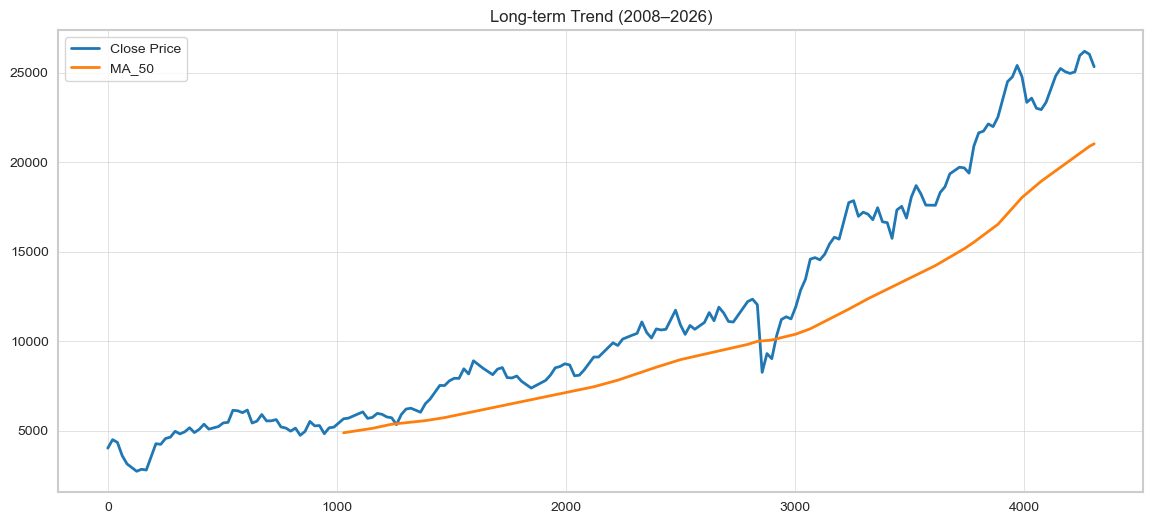

In [139]:
sns.set_style("whitegrid")

# Long-term
plt.figure(figsize=(14,6))
plt.plot(normal_sample['Close'], label='Close Price')
plt.plot(normal_sample['MA_50'], label='MA_50')
plt.title("Long-term Trend (2008–2026)")
plt.legend()
plt.savefig(" undersampling_long_term_trend.png", dpi=300)
plt.show()

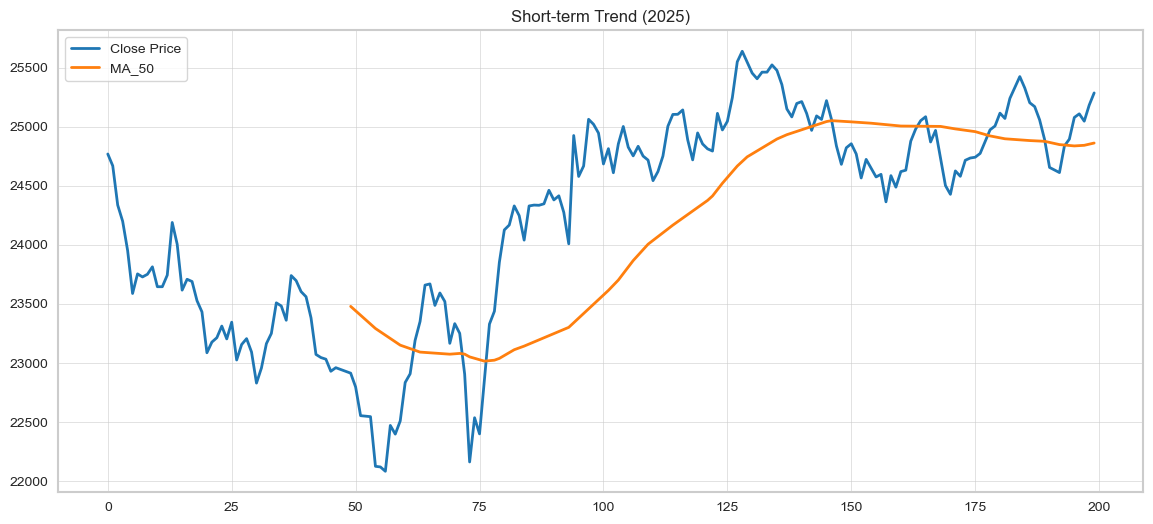

In [141]:
# Short-term
plt.figure(figsize=(14,6))
plt.plot(short['Close'], label='Close Price')
plt.plot(short['MA_50'], label='MA_50')
plt.title("Short-term Trend (2025)")
plt.legend()
plt.savefig(" undersampling short_term_trend.png", dpi=300)
plt.show()

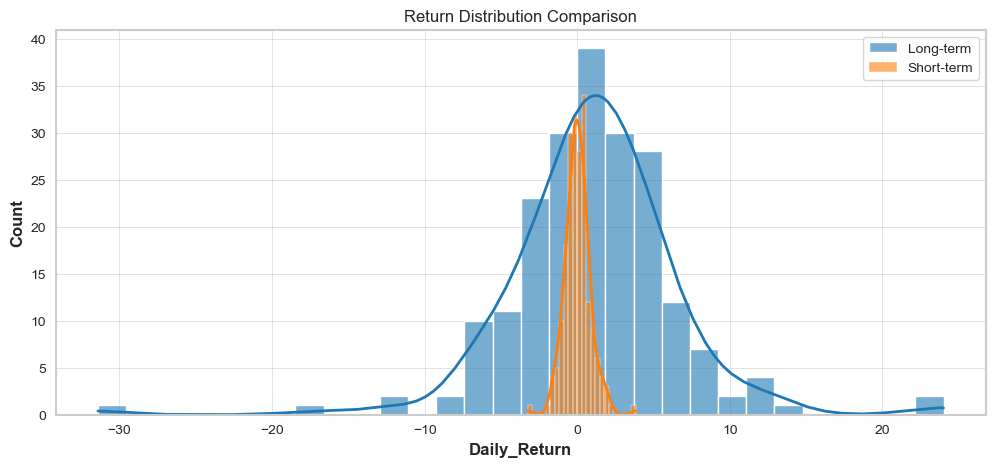

In [143]:
# Returns Distribution
plt.figure(figsize=(12,5))
sns.histplot(normal_sample['Daily_Return'], kde=True, label='Long-term', alpha=0.6)
sns.histplot(short['Daily_Return'], kde=True, label='Short-term', alpha=0.6)
plt.legend()
plt.title("Return Distribution Comparison")
plt.savefig(" undersampling returns.png", dpi=300)
plt.show()

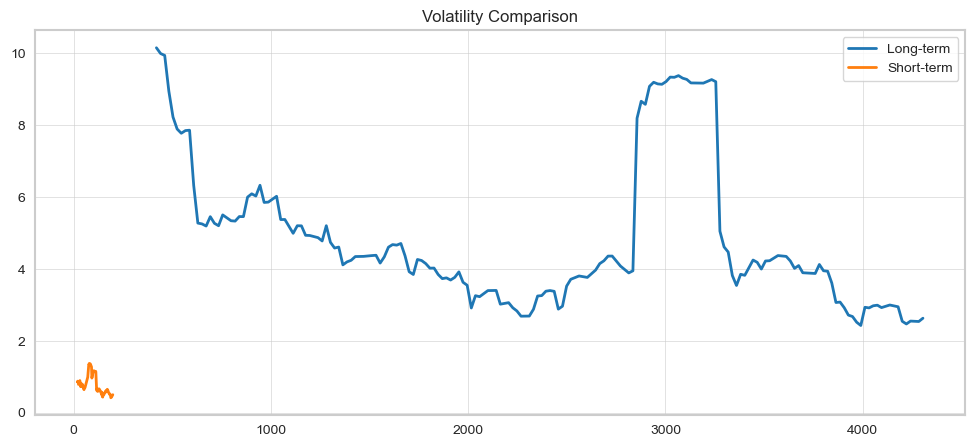

In [144]:
# Volatility
plt.figure(figsize=(12,5))
normal_sample['Volatility_20'].plot(label='Long-term')
short['Volatility_20'].plot(label='Short-term')
plt.legend()
plt.title("Volatility Comparison")
plt.savefig(" undersampling volatility.png", dpi=300)
plt.show()

In [146]:
summary = pd.DataFrame({
    "Metric": ["Mean Return", "Volatility", "Max Price", "Min Price"],
    "Long-term": [
        normal_sample['Daily_Return'].mean(),
        normal_sample['Daily_Return'].std(),
        normal_sample['Close'].max(),
        normal_sample['Close'].min()
    ],
    "Short-term": [
          short['Daily_Return'].mean(),
          short['Daily_Return'].std(),
          short['Close'].max(),
          short['Close'].min()
    ]
})

print("\n=== Summary ===")
print(summary)

summary.to_csv(" undersampling summary_table.csv", index=False)


=== Summary ===
        Metric     Long-term    Short-term
0  Mean Return      1.057225      0.013697
1   Volatility      5.535352      0.817031
2    Max Price  26205.300781  25637.800000
3    Min Price   2736.699951  22082.650000


In [147]:
trend_dist = pd.DataFrame({
    "Long-term (%)": normal_sample['Trend'].value_counts(normalize=True) * 100,
    "Short-term (%)": short['Trend'].value_counts(normalize=True) * 100
}).round(2)

print("\nTrend Distribution")
print(trend_dist)

trend_dist.to_csv(" undersampling trend_distribution.csv")


Trend Distribution
           Long-term (%)  Short-term (%)
Trend                                   
Downtrend           1.46             6.5
Sideways           24.76            70.0
Uptrend            73.79            23.5


# oversampling 

In [148]:
from imblearn.over_sampling import SMOTE

In [150]:
big = data
small = dataset

In [151]:
print(big.shape, small.shape)

(4323, 9) (200, 10)
